In [180]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, LSTM, TimeDistributed, Conv3D, MaxPooling3D, Concatenate
from sklearn.metrics import mean_squared_error, r2_score
# Load the Excel file
# file_path = 'dv0_witoutstraw.xlsx'  
file_path = 'dv0_withoutstraw_sipCAdded.xlsx' # Use the correct path for your environment
data = pd.read_excel(file_path)
data

,Unnamed: 0,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,...,Container_Weight,drink,temp,prev,next,sip_start,sip_end,sip_id,dV,TOTAL_SIP_TIME
0,0,1747823631000,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
1,1,1747823631200,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
2,2,1747823631400,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
3,3,1747823631600,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
4,4,1747823631800,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79365,79365,17480259581000,133,230,129,245,117,114,106,97,...,12.7,water,n,0,0,False,False,7,0.0,0
79366,79366,17480259641000,224,230,205,245,199,207,218,185,...,12.7,water,n,0,0,False,False,7,0.0,0
79367,79367,17480259681000,133,204,205,1886,165,158,182,162,...,12.7,water,n,0,0,False,False,7,0.0,0
79368,79368,17480259781000,214,204,1890,219,199,207,196,182,...,12.7,water,n,0,0,False,False,7,0.0,0


In [181]:
df = data[data['Label'] == 1]
df

,Unnamed: 0,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,...,Container_Weight,drink,temp,prev,next,sip_start,sip_end,sip_id,dV,TOTAL_SIP_TIME
241,241,1747823679200,2487,165,348,2497,297,255,279,245,...,19.8,coke-r,c,0,1,True,False,1,69.904762,26
242,242,1747823679400,2487,165,348,2497,297,255,279,245,...,19.8,coke-r,c,1,1,False,False,1,69.904762,26
243,243,1747823679600,265,200,234,245,277,255,279,245,...,19.8,coke-r,c,1,1,False,False,1,69.904762,26
244,244,1747823679800,178,200,215,211,202,248,243,225,...,19.8,coke-r,c,1,1,False,False,1,69.904762,26
245,245,1747823680000,178,200,210,192,176,207,243,225,...,19.8,coke-r,c,1,1,False,False,1,69.904762,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79222,79222,1748026308400,224,211,219,228,223,217,219,226,...,12.7,water,n,1,1,False,False,7,26.100000,9
79223,79223,1748026308600,224,210,218,231,211,225,219,213,...,12.7,water,n,1,1,False,False,7,26.100000,9
79224,79224,1748026308800,205,210,217,228,211,225,217,211,...,12.7,water,n,1,1,False,False,7,26.100000,9
79225,79225,1748026309000,202,210,217,215,209,217,217,211,...,12.7,water,n,1,1,False,False,7,26.100000,9


In [182]:
df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})

df["Container_Weight"] = df["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})
# df["Container_Weight"] = df["Container_Weight"].map({
#     7.7: 0,   # First type
#     10.6: 1,  # Second type
#     10.9: 2,  # Changed this to represent a distinct type
#     12.7: 3,  # Third type
#     19.8: 4,  # Fourth type
#     359: 5    # Fifth type
# })
df["Label"] = df["Label"].map({"Drinking": 1, "Not_Drinking": 0})
df['temp'] = df ['temp'].map({'h':2, 'c':0, 'n': 1})
# print(data.head())
# Group by Participant_ID and sip_id to count time steps and extract dV and Label
grouped_data = df.groupby(['Participant_ID', 'sip_id']).agg(
    time_steps=('sip_id', 'size'),  # Count of rows (time steps)
    dV=('dV', 'first'),  # Taking the first dV value for each group
    Gender=('Gender', 'first'), 
    temp=('temp', 'first') ,
    Container_Weight=('Container_Weight', 'first'),
    Label=('Label', 'first')  # Assuming the label is consistent, take the first
).reset_index()


# Merge SIP_TIME back to the grouped data
# grouped_data = pd.merge(grouped_data, sip_counts, on='sip_id', how='left').fillna(0)
# grouped_data['SIP_TIME'] = grouped_data['SIP_TIME'].astype(int)
# Display the grouped data before creating X and y
print("\nGrouped Data Sample:")
print(grouped_data.head(200))
# grouped_data.to_excel('dv0_witoutstraw_final.xlsx')
# Prepare features (X) and target (y)
X = grouped_data[['time_steps','Gender', 'Container_Weight','temp', 'sip_id']]  # Features
y = grouped_data['dV']             # Target variable

# Display X and y before proceeding
print("\nFeatures (X):")
print(X.head(50))
print("\nTarget (y):")
print(y.head(50))



Grouped Data Sample:
     Participant_ID  sip_id  time_steps          dV  Gender  temp  \
0                 6       1          26   69.904762       1     0   
1                 6       2          26   58.000000       1     0   
2                 6       3          27   61.904762       1     0   
3                 6       4          29   68.857143       1     0   
4                 6       5          23   44.571429       1     0   
..              ...     ...         ...         ...     ...   ...   
195              36      16          16   36.630754       1     0   
196              36      17          14   28.795299       1     0   
197              37       1          20  129.300000       0     1   
198              37       2          23  160.200000       0     1   
199              37       3          22  141.600000       0     1   

     Container_Weight  Label  
0                   3    NaN  
1                   3    NaN  
2                   3    NaN  
3                   3    

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_2565/2663744025.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_2565/2663744025.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Container_Weight"] = df["Container_Weight"].map({
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_2565/2663744025.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy o

In [183]:
print(grouped_data['time_steps'].describe())

count    315.000000
mean      16.660317
std        7.482603
min        1.000000
25%       12.000000
50%       15.000000
75%       19.000000
max       60.000000
Name: time_steps, dtype: float64


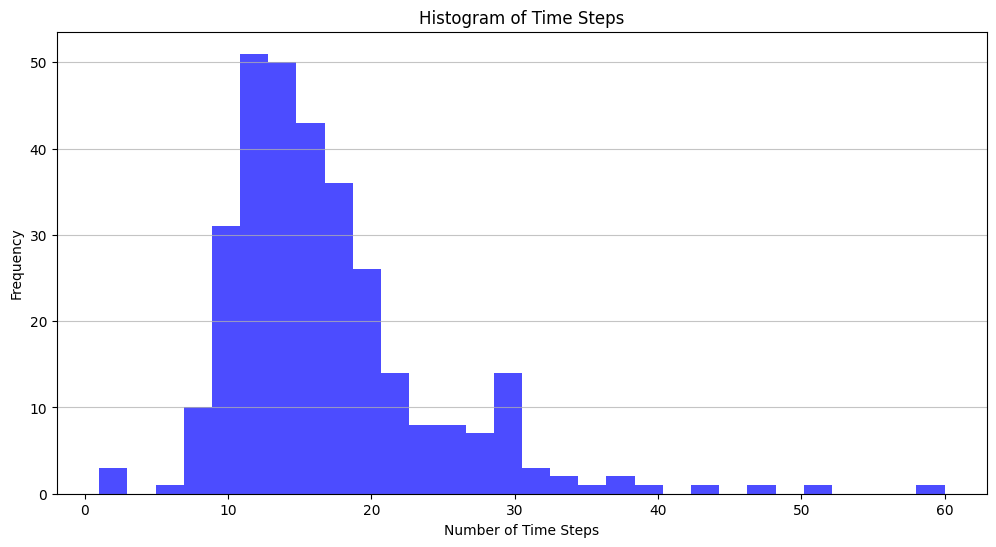

In [184]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(grouped_data['time_steps'], bins=30, alpha=0.7, color='blue')
plt.title('Histogram of Time Steps')
plt.xlabel('Number of Time Steps')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [189]:
max_time_steps = DF.groupby(['Participant_ID', 'sip_id']).size().max()  # Corrected to group by both Participant_ID and sip_id
print(f"Global Maximum Time Steps: {max_time_steps}")

Global Maximum Time Steps: 60


In [186]:
import numpy as np
import pandas as pd

# Assuming you have your DataFrame 'DF' loaded with participant and sip IDs
# Prepare lists to hold padded sequences and target volumes
padded_sequences = []
target_volumes = []
DF = df

# Calculate the global maximum time steps across all sip_ids for all participants
max_time_steps = DF.groupby(['Participant_ID', 'sip_id']).size().max()
print(f"Global Maximum Time Steps: {max_time_steps}")

# Iterate through unique participant IDs
for participant_id in DF['Participant_ID'].unique():
    participant_data = DF[DF['Participant_ID'] == participant_id]

    # Iterate through each sip ID for the participant
    for sip_id in participant_data['sip_id'].unique():
        sip_data = participant_data[participant_data['sip_id'] == sip_id]
        time_steps = len(sip_data)

        # Extract zoning data (assuming you have 64 Zones)
        zones = sip_data[[f'Zone_{i}' for i in range(64)]].values
        
        print(f"Participant ID: {participant_id} | Sip ID: {sip_id} | Time Steps: {time_steps} | Zones Shape: {zones.shape}")

        # Padding for zones
        if time_steps < max_time_steps:
            zone_padding = np.zeros((max_time_steps - time_steps, zones.shape[1]))  # Padding for zones
            padded_zones = np.vstack([zones, zone_padding])  # Pad the zones data
        else:
            padded_zones = zones[-max_time_steps:]  # Take the last max_time_steps values
        
        print(f"Padded Zones Shape: {padded_zones.shape}")

        # Combine the zones with additional features for CNN input
        # No flattening; we maintain the 2D shape of zones
        additional_features = np.array([[sip_data['Container_Weight'].values[0], 
                                          sip_data['Gender'].values[0], 
                                          sip_data['temp'].values[0], 
                                          participant_id]])  # Shape: (1, 4)

        # Repeat the additional features to match max_time_steps
        repeated_features = np.repeat(additional_features, max_time_steps, axis=0)  # Shape: (max_time_steps, 4)

        # Combine zones and repeated features
        combined_data = np.concatenate([padded_zones, repeated_features], axis=1)  # Shape: (max_time_steps, 68)
        
        print(f"Combined Data Shape: {combined_data.shape}")
        padded_sequences.append(combined_data)  # Append to the final list
        
        # Calculate mean volume for the target
        target_volumes.append(np.mean(sip_data['dV'].values))

# Convert padded_sequences to numpy array and target volumes
padded_sequences = np.array(padded_sequences)
target_volumes = np.array(target_volumes)

# Print final shapes before preparing the model
print(f"Final Padded Sequences Shape: {padded_sequences.shape}")
print(f"Final Target Volumes Shape: {target_volumes.shape}")

# Prepare the data for modeling
# The padded_sequences maintain the shape (num_samples, max_time_steps, 68)
# Here 68 = 64 zones + 4 additional features

X = padded_sequences  # This is your final input for CNN
y = target_volumes    # Target volumes remain the same

# Example model preparation for CNN
import keras
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout

# Define the model
# Adjusted for 2D CNN input; input_shape should match padded_sequences
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(max_time_steps, 68, 1)))
# Add more layers as needed
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear'))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary()  # View the model structure

# Reshape X for Conv2D compatibility
X = X.reshape(X.shape[0], max_time_steps, 68, 1)  # Reshape to (num_samples, height, width, channels)
# # Train the model
# model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2)

Global Maximum Time Steps: 60
Participant ID: 6 | Sip ID: 1 | Time Steps: 26 | Zones Shape: (26, 64)
Padded Zones Shape: (60, 64)
Combined Data Shape: (60, 68)
Participant ID: 6 | Sip ID: 2 | Time Steps: 26 | Zones Shape: (26, 64)
Padded Zones Shape: (60, 64)
Combined Data Shape: (60, 68)
Participant ID: 6 | Sip ID: 3 | Time Steps: 27 | Zones Shape: (27, 64)
Padded Zones Shape: (60, 64)
Combined Data Shape: (60, 68)
Participant ID: 6 | Sip ID: 4 | Time Steps: 29 | Zones Shape: (29, 64)
Padded Zones Shape: (60, 64)
Combined Data Shape: (60, 68)
Participant ID: 6 | Sip ID: 5 | Time Steps: 23 | Zones Shape: (23, 64)
Padded Zones Shape: (60, 64)
Combined Data Shape: (60, 68)
Participant ID: 6 | Sip ID: 6 | Time Steps: 13 | Zones Shape: (13, 64)
Padded Zones Shape: (60, 64)
Combined Data Shape: (60, 68)
Participant ID: 7 | Sip ID: 1 | Time Steps: 24 | Zones Shape: (24, 64)
Padded Zones Shape: (60, 64)
Combined Data Shape: (60, 68)
Participant ID: 7 | Sip ID: 2 | Time Steps: 21 | Zones Shape

/opt/anaconda3/envs/ACM1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 58, 66, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 122496)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 64)             │     7,839,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,840,193 (29.91 MB)

 Trainable params: 7,840,193 (29.91 MB)

 Non-trainable params: 0 (0.00 B)

In [161]:
import numpy as np
from keras.models import Sequential

# Assume padded_sequences and target_volumes are already defined from your previous code
# Set a seed for reproducibility in deterministic behavior if required
# np.random.seed(42)  # Uncomment if you wish to use random seed for reproducibility

# Calculate the split index for the training and test set
split_ratio = 0.8  # Using 80% for training and 20% for testing
split_index = int(len(padded_sequences) * split_ratio)

# Split the data into training and testing sets
X_train = padded_sequences[:split_index]  # Training data
y_train = target_volumes[:split_index]    # Training targets

X_test = padded_sequences[split_index:]    # Testing data
y_test = target_volumes[split_index:]      # Testing targets

# Confirm the shapes of the training and testing datasets
print(f"Training data shape: {X_train.shape}, Training target shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing target shape: {y_test.shape}")

# Example model creation (if not created before or if you need to recreate it)
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(60, 68, 1)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear'))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Evaluate the model on the test dataset
loss, mae = model.evaluate(X_test.reshape(X_test.shape[0], 60, 68, 1), y_test)

print(f"Test Loss: {loss}, Test MAE: {mae}")

Training data shape: (252, 60, 68), Training target shape: (252,)
Testing data shape: (63, 60, 68), Testing target shape: (63,)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2641.7778 - mae: 40.6992
Test Loss: 2945.34912109375, Test MAE: 43.88243103027344


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Your CNN Model Evaluation Metrics:
Mean Squared Error (MSE): 613.8734
Root Mean Squared Error (RMSE): 24.7765
R-squared (R²): -0.9519
Root Mean Squared Percentage Error (RMSPE): 72.3131%
   Actual  Predicted
0    36.0   7.971748
1    33.7  10.558248
2    23.0  18.067005
3    13.9   8.085768
4    17.7   5.752557


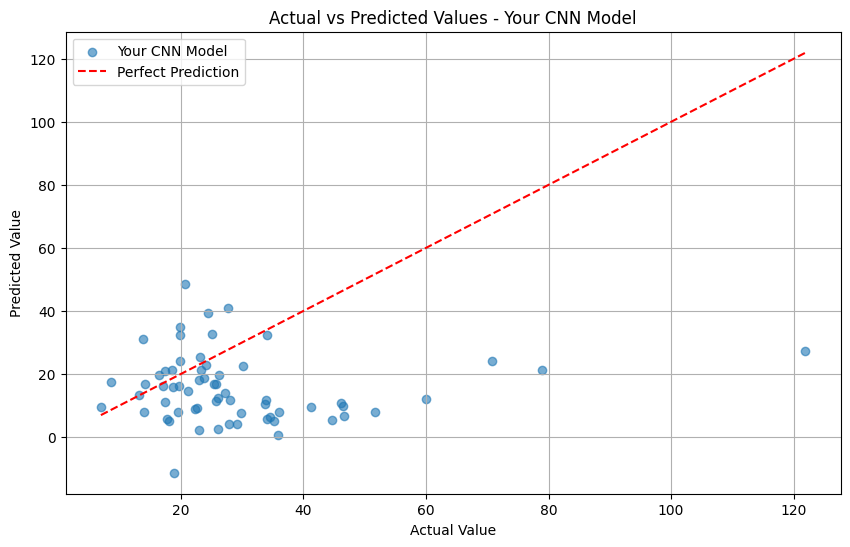

In [190]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Assume model predictions have been made
y_pred = model.predict(X_test.reshape(X_test.shape[0], 60, 68, 1))

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmspe = np.sqrt(np.mean((y_test - y_pred.flatten()) ** 2) / np.mean(y_test ** 2)) * 100

# Print evaluation metrics for the model
model_name = "Your CNN Model"  # Replace with your actual model name
print(f"\n{model_name} Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

# Create a comparison DataFrame for the first few rows
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.flatten()})
print(comparison_df.head(5))

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title(f'Actual vs Predicted Values - {model_name}')
plt.legend()
plt.grid()
plt.show()

Training data shape: (252, 60, 68), Training target shape: (252,)
Testing data shape: (63, 60, 68), Testing target shape: (63,)
Epoch 1/50


/opt/anaconda3/envs/ACM1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 3148560.0000 - mae: 996.2054 - val_loss: 1473.4950 - val_mae: 29.2258
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 18274.9922 - mae: 76.4612 - val_loss: 753.2450 - val_mae: 19.8819
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 13680.7148 - mae: 52.6882 - val_loss: 678.8143 - val_mae: 18.5783
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 3607.6868 - mae: 33.5918 - val_loss: 920.8058 - val_mae: 22.5520
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1730.2346 - mae: 28.4982 - val_loss: 478.6450 - val_mae: 16.0559
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 1730.3184 - mae: 25.8342 - val_loss: 457.1642 - val_mae: 14.8892
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 1327.3334 - mae: 27.0787 - val_loss: 440.5074 - val_mae: 14.8736
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 1373.1218 - mae: 24.6554 - val_loss: 391.3913 - val_mae: 14.3

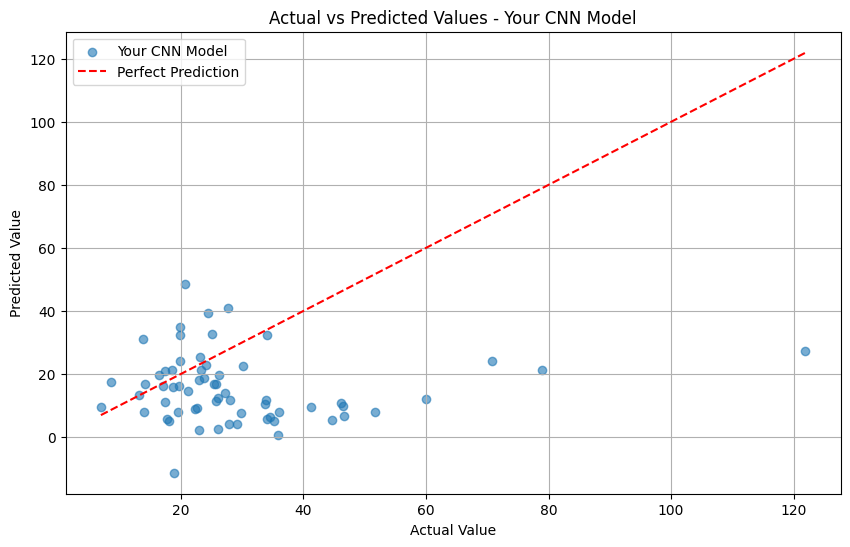

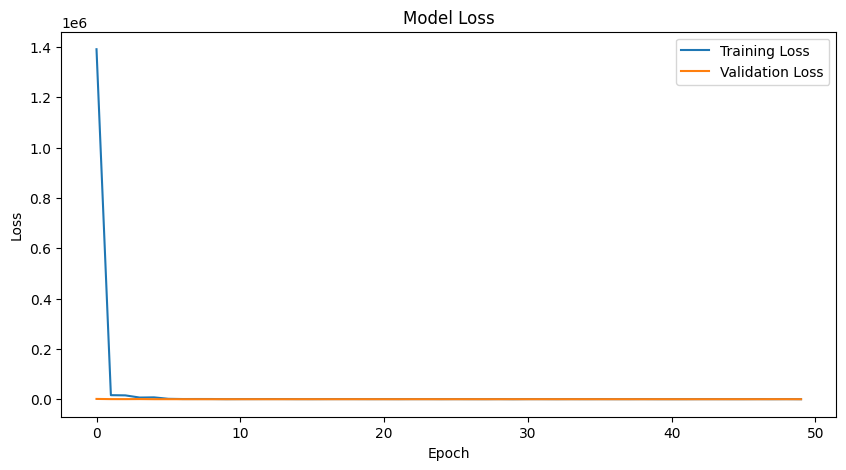

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score

# Assume padded_sequences and target_volumes are already defined from your previous code
# Set a seed for reproducibility if necessary
# np.random.seed(42)  # Uncomment if you wish to use a random seed for reproducibility

# Calculate the split index for the training and test set
split_ratio = 0.8  # Use 80% for training and 20% for testing
split_index = int(len(padded_sequences) * split_ratio)

# Split the data into training and testing sets
X_train = padded_sequences[:split_index]  # Training data
y_train = target_volumes[:split_index]    # Training targets

X_test = padded_sequences[split_index:]    # Testing data
y_test = target_volumes[split_index:]      # Testing targets

# Confirm the shapes of the training and testing datasets
print(f"Training data shape: {X_train.shape}, Training target shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing target shape: {y_test.shape}")

# Reshape X train and test for Conv2D compatibility
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)  # (num_samples, height, width, channels)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Define the model
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(60, 68, 1)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear'))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model
epochs = 50 # Set the number of epochs you want to train for
batch_size = 2  # Set the batch size
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1)

# Evaluate the model on the test dataset
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmspe = np.sqrt(np.mean((y_test - y_pred.flatten()) ** 2) / np.mean(y_test ** 2)) * 100

# Print evaluation metrics for the model
model_name = "Your CNN Model"  # Replace with your actual model name
print(f"\n{model_name} Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

# Create a comparison DataFrame for the first few rows
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.flatten()})
print(comparison_df.head(5))

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title(f'Actual vs Predicted Values - {model_name}')
plt.legend()
plt.grid()
plt.show()

# Optionally plot the training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [178]:
# Assuming padded_sequences are structured correctly
# Verify the original shape before reshaping
print("Original padded_sequences shape:", padded_sequences.shape)

# Define the correct reshape based on actual shape,
# The below is an example shape: adjust according to your actual data
n_samples = padded_sequences.shape[0]  # Total number of samples
X = padded_sequences.reshape((n_samples, 60, 68, 68, 1))  # Change as necessary

# Now, split the data
split_index = int(len(X) * 0.8)  # 80% train
X_train = X[:split_index]
y_train = target_volumes[:split_index]
X_test = X[split_index:]
y_test = target_volumes[split_index:]

# Define the 3D CNN model
model_3d_cnn = Sequential()
model_3d_cnn.add(Conv3D(32, kernel_size=(3, 3, 3), activation='relu', input_shape=(60, 68, 68, 1)))
model_3d_cnn.add(MaxPooling3D(pool_size=(2, 2, 2)))
model_3d_cnn.add(Conv3D(64, kernel_size=(3, 3, 3), activation='relu'))
model_3d_cnn.add(MaxPooling3D(pool_size=(2, 2, 2)))
model_3d_cnn.add(Conv3D(128, kernel_size=(3, 3, 3), activation='relu'))
model_3d_cnn.add(MaxPooling3D(pool_size=(2, 2, 2)))
model_3d_cnn.add(Flatten())
model_3d_cnn.add(Dense(256, activation='relu'))
model_3d_cnn.add(Dropout(0.5))
model_3d_cnn.add(Dense(1, activation='linear'))  # Output layer

# Compile and fit the model
model_3d_cnn.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
history_3d_cnn = model_3d_cnn.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1)

# Evaluate the model
y_pred_3d_cnn = model_3d_cnn.predict(X_test)

# Print evaluation metrics afterwards

Original padded_sequences shape: (315, 60, 68)


ValueError: cannot reshape array of size 1285200 into shape (315,60,68,68,1)

Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 5053704.5000 - mae: 1330.0027 - val_loss: 30075.7129 - val_mae: 124.4310
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 75826.5234 - mae: 163.0568 - val_loss: 55839.4805 - val_mae: 166.0126
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 26385.7031 - mae: 111.2158 - val_loss: 2358.7400 - val_mae: 35.7265
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 2388.8147 - mae: 33.4664 - val_loss: 986.8448 - val_mae: 23.8289
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 1166.2266 - mae: 21.8440 - val_loss: 1497.6066 - val_mae: 27.5668
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 700.9919 - mae: 16.7538 - val_loss: 1254.0557 - val_mae: 24.8485
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 366.6713 - mae: 12.6974 - val_loss: 886.8093 - val_mae: 21.4639
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 210.8734 - mae: 10.5118 - val_loss: 1113.

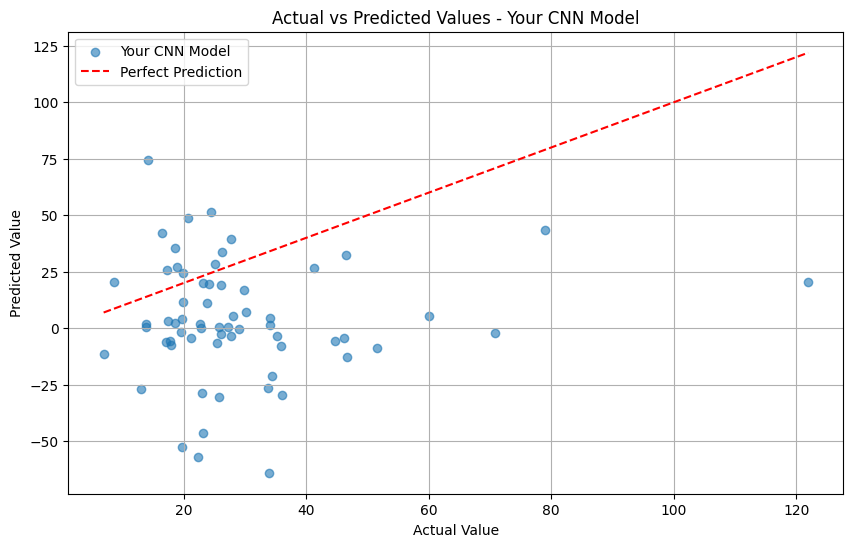

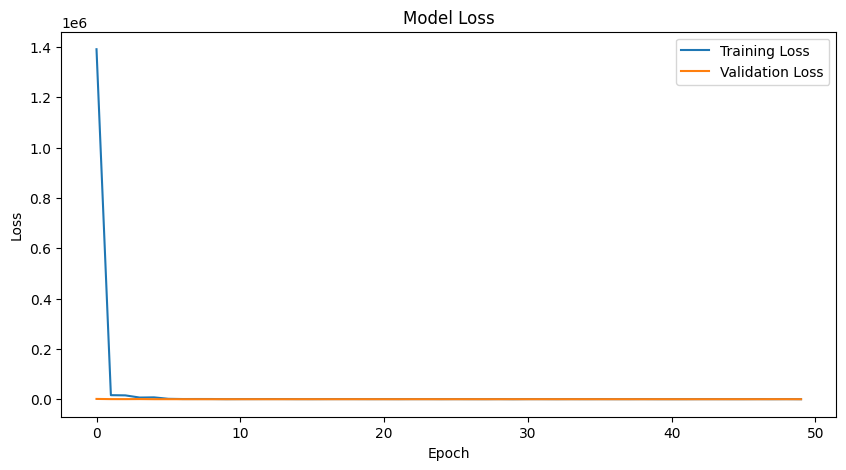

In [209]:
from keras.layers import Concatenate
epochs = 10  # Set the number of epochs you want to train for
batch_size = 2  # Set the batch size
# Define inputs for spatial and temporal streams
input_spatial = Input(shape=(60, 68, 1))   # For the spatial stream
input_temporal = Input(shape=(60, 68, 1))   # For the temporal stream (which could use optical flow data)

# Spatial Stream
spatial_out = Conv2D(32, (3, 3), activation='relu')(input_spatial)
spatial_out = MaxPooling2D(pool_size=(2, 2))(spatial_out)
spatial_out = Flatten()(spatial_out)

# Temporal Stream
temporal_out = Conv2D(32, (3, 3), activation='relu')(input_temporal)
temporal_out = MaxPooling2D(pool_size=(2, 2))(temporal_out)
temporal_out = Flatten()(temporal_out)

# Combine both streams
combined = Concatenate()([spatial_out, temporal_out])
combined_out = Dense(256, activation='relu')(combined)
output = Dense(1, activation='linear')(combined_out)

# Define the two-stream model
two_stream_model = Model(inputs=[input_spatial, input_temporal], outputs=output)

# Compile the model
two_stream_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model (requires both streams of inputs)
history_two_stream = two_stream_model.fit([X_train_lstm, X_train_lstm], y_train_lstm, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1)

# Evaluate the model
y_pred_two_stream = two_stream_model.predict([X_test_lstm, X_test_lstm])  # Use test set for both streams, modifying as needed

# Calculate evaluation metrics for the Two-Stream Network
mse_two_stream = mean_squared_error(y_test_lstm, y_pred_two_stream)
rmse_two_stream = np.sqrt(mse_two_stream)
r2_two_stream = r2_score(y_test_lstm, y_pred_two_stream)

print(f"\n{model_name} Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

# Create a comparison DataFrame for the first few rows
comparison_df = pd.DataFrame({'Actual': y_test_lstm, 'Predicted': y_pred_two_stream.flatten()})
print(comparison_df.head(5))

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_lstm, y_pred_two_stream, label=model_name, alpha=0.6)
plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], color='red', ls='--', label='Perfect Prediction')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title(f'Actual vs Predicted Values - {model_name}')
plt.legend()
plt.grid()
plt.show()

# Optionally plot the training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

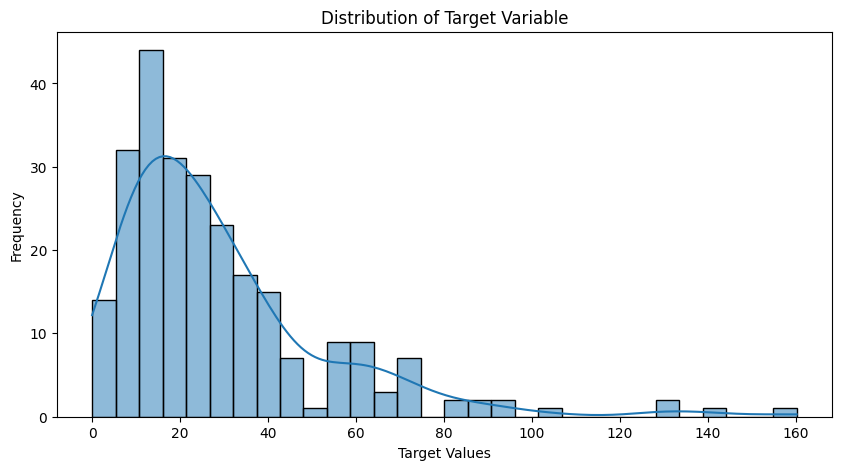

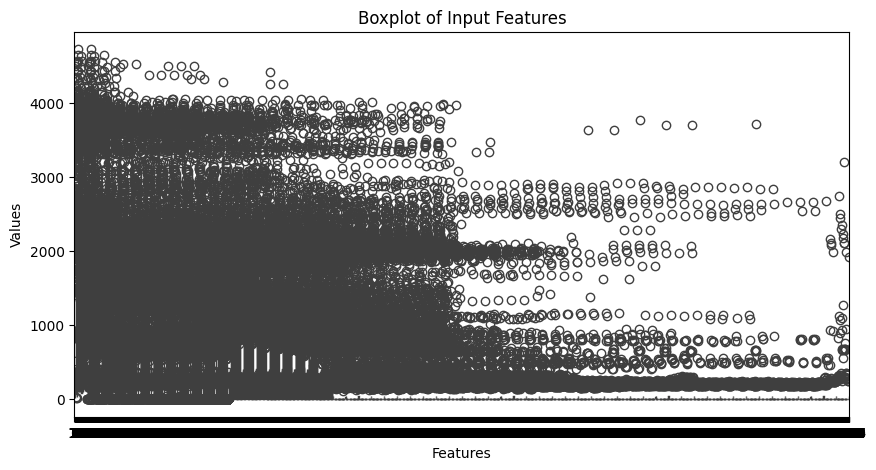

In [215]:
import seaborn as sns

# Distribution of target variable
plt.figure(figsize=(10, 5))
sns.histplot(y_train_lstm, bins=30, kde=True)
plt.title('Distribution of Target Variable')
plt.xlabel('Target Values')
plt.ylabel('Frequency')
plt.show()

# Distribution of input features
plt.figure(figsize=(10, 5))
sns.boxplot(data=X_train_lstm.reshape(-1, 60 * 68))  # Flatten for visualization
plt.title('Boxplot of Input Features')
plt.xlabel('Features')
plt.ylabel('Values')
plt.show()

In [216]:
# Scale your input features
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_train_lstm_scaled = scaler_X.fit_transform(X_train_lstm.reshape(-1, 60 * 68)).reshape(X_train_lstm.shape)
X_test_lstm_scaled = scaler_X.transform(X_test_lstm.reshape(-1, 60 * 68)).reshape(X_test_lstm.shape)

In [217]:
from keras.layers import Dropout

# Define inputs
input_spatial = Input(shape=(60, 68, 1))
input_temporal = Input(shape=(60, 68, 1))

# Spatial Stream
spatial_out = Conv2D(64, (3, 3), activation='relu')(input_spatial)  # Increased filters
spatial_out = MaxPooling2D(pool_size=(2, 2))(spatial_out)
spatial_out = Dropout(0.25)(spatial_out)  # Dropout for regularization
spatial_out = Flatten()(spatial_out)

# Temporal Stream
temporal_out = Conv2D(64, (3, 3), activation='relu')(input_temporal)  # Increased filters
temporal_out = MaxPooling2D(pool_size=(2, 2))(temporal_out)
temporal_out = Dropout(0.25)(temporal_out)  # Dropout for regularization
temporal_out = Flatten()(temporal_out)

# Combine both streams
combined = Concatenate()([spatial_out, temporal_out])
combined_out = Dense(512, activation='relu')(combined)  # Increased units in dense layer
output = Dense(1, activation='linear')(combined_out)  # Linear activation

# Model compilation remains the same
two_stream_model = Model(inputs=[input_spatial, input_temporal], outputs=output)
two_stream_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [222]:
# Train the model using scaled inputs
history_two_stream = two_stream_model.fit(
    [X_train_lstm_scaled, X_train_lstm_scaled],  # Use scaled inputs
    y_train_lstm_scaled,                         # Use scaled targets
    epochs=100,                                   # Increase epochs
    batch_size=2,                               # Adjust batch size
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 0.0021 - mae: 0.0310 - val_loss: 0.0133 - val_mae: 0.0980
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0152 - mae: 0.0935 - val_loss: 0.0157 - val_mae: 0.1068
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0039 - mae: 0.0447 - val_loss: 0.0141 - val_mae: 0.1085
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - loss: 0.0036 - mae: 0.0402 - val_loss: 0.0259 - val_mae: 0.1362
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - loss: 0.0033 - mae: 0.0335 - val_loss: 0.0200 - val_mae: 0.1322
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - loss: 0.0016 - mae: 0.0257 - val_loss: 0.0191 - val_mae: 0.1279
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - loss: 0.0012 - mae: 0.0242 - val_loss: 0.0197 - val_mae: 0.1288
Epoch 8/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - loss: 0.0014 - mae: 0.0236 - val_loss: 0.0203 - val_mae: 0.1313
Epoch 9/100
101/101 ━━━━

In [ ]:
# Evaluate the model
y_pred_two_stream_scaled = two_stream_model.predict([X_test_lstm_scaled, X_test_lstm_scaled])  # Predict using scaled test set

# Inverse transform predictions
y_pred_two_stream = scaler.inverse_transform(y_pred_two_stream_scaled)

# Calculate evaluation metrics
mse_two_stream = mean_squared_error(y_test_lstm, y_pred_two_stream)
rmse_two_stream = np.sqrt(mse_two_stream)
r2_two_stream = r2_score(y_test_lstm, y_pred_two_stream)
rmspe = np.sqrt(np.mean((y_test_lstm - y_pred_two_stream.flatten()) ** 2) / np.mean(y_test_lstm ** 2)) * 100
# Output evaluation metrics
print(f"\nEvaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse_two_stream:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_two_stream:.4f}")
print(f"R-squared (R²): {r2_two_stream:.4f}")
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")
# Create a comparison DataFrame for the first few rows of predictions
comparison_df = pd.DataFrame({'Actual': y_test_lstm.flatten(), 'Predicted': y_pred_two_stream.flatten()})
print(comparison_df.head(5))

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_lstm, y_pred_two_stream, label='Two-Stream Model', alpha=0.6)
plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual vs Predicted Values - Two-Stream Model')
plt.legend()
plt.grid()
plt.show()

In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, LSTM, Dense, Dropout, TimeDistributed
from sklearn.metrics import mean_squared_error, r2_score

# Assume padded_sequences and target_volumes are already defined from your previous code
# Set a seed for reproducibility if necessary
# np.random.seed(42)  # Uncomment if you wish to use a random seed for reproducibility

# Calculate the split index for the training and test set
split_ratio = 0.8  # Use 80% for training and 20% for testing
split_index = int(len(padded_sequences) * split_ratio)

# Split the data into training and testing sets
X_train = padded_sequences[:split_index]  # Training data
y_train = target_volumes[:split_index]    # Training targets

X_test = padded_sequences[split_index:]    # Testing data
y_test = target_volumes[split_index:]      # Testing targets

# Confirm the shapes of the training and testing datasets
print(f"Training data shape: {X_train.shape}, Training target shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing target shape: {y_test.shape}")

# Reshape X train and test for Conv2D compatibility
# Assuming padded_sequences is (num_samples, height, width, channels) 
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)  # (num_samples, height, width, channels)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Further reshape to add time steps if needed
# Here we assume that each sample represents a time series of images
# For example, if each image is part of a sequence length of 5:
# Time steps = 5, adjust your input shape accordingly
time_steps = 5  # Adjust this based on your specific scenario
num_samples = X_train.shape[0] // time_steps  # Total steps considering sequence length

# Reshape for LSTM: (samples, time steps, features)
X_train_lstm = X_train[:num_samples * time_steps].reshape(num_samples, time_steps, X_train.shape[1], X_train.shape[2], 1)
y_train_lstm = y_train[:num_samples * time_steps].reshape(num_samples, time_steps)

X_test_lstm = X_test[:num_samples * (len(X_test) // time_steps)].reshape(-1, time_steps, X_test.shape[1], X_test.shape[2], 1)
y_test_lstm = y_test[:num_samples * (len(X_test) // time_steps)].reshape(-1, time_steps)

# Define the model
model = Sequential()
model.add(TimeDistributed(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'), input_shape=(time_steps, 60, 68, 1)))  # Using TimeDistributed for Conv2D
model.add(TimeDistributed(Flatten()))  # Flatten to prepare for LSTM
model.add(LSTM(50, return_sequences=False))  # LSTM layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear'))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model
epochs = 50  # Set the number of epochs you want to train for
batch_size = 16  # Adjust for LSTM; generally larger
history = model.fit(X_train_lstm, y_train_lstm[:, -1],  # Predict last output in the sequence
                    epochs=epochs, 
                    batch_size=batch_size, 
                    validation_split=0.2, 
                    verbose=1)

# Evaluate the model on the test dataset
y_pred = model.predict(X_test_lstm)

# Calculate evaluation metrics
mse = mean_squared_error(y_test_lstm[:, -1], y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_lstm[:, -1], y_pred)
rmspe = np.sqrt(np.mean((y_test_lstm[:, -1] - y_pred.flatten()) ** 2) / np.mean(y_test_lstm[:, -1] ** 2)) * 100

# Print evaluation metrics for the model
model_name = "Two-Stream CNN with LSTM"  # Replace with your actual model name
print(f"\n{model_name} Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

# Create a comparison DataFrame for the first few rows
comparison_df = pd.DataFrame({'Actual': y_test_lstm[:, -1], 'Predicted': y_pred.flatten()})
print(comparison_df.head(5))

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_lstm[:, -1], y_pred, label=model_name, alpha=0.6)
plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 
         [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 
         color='red', ls='--', label='Perfect Prediction')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title(f'Actual vs Predicted Values - {model_name}')
plt.legend()
plt.grid()
plt.show()

# Optionally plot the training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Training data shape: (252, 60, 68), Training target shape: (252,)
Testing data shape: (63, 60, 68), Testing target shape: (63,)


ValueError: cannot reshape array of size 257040 into shape (5,60,68,1)

In [202]:
print(f"X_train shape: {X_train}")
print(f"y_train shape: {y_train}")

X_train shape: [[[[2.487e+03]
   [1.650e+02]
   [3.480e+02]
   ...
   [1.000e+00]
   [0.000e+00]
   [6.000e+00]]

  [[2.487e+03]
   [1.650e+02]
   [3.480e+02]
   ...
   [1.000e+00]
   [0.000e+00]
   [6.000e+00]]

  [[2.650e+02]
   [2.000e+02]
   [2.340e+02]
   ...
   [1.000e+00]
   [0.000e+00]
   [6.000e+00]]

  ...

  [[0.000e+00]
   [0.000e+00]
   [0.000e+00]
   ...
   [1.000e+00]
   [0.000e+00]
   [6.000e+00]]

  [[0.000e+00]
   [0.000e+00]
   [0.000e+00]
   ...
   [1.000e+00]
   [0.000e+00]
   [6.000e+00]]

  [[0.000e+00]
   [0.000e+00]
   [0.000e+00]
   ...
   [1.000e+00]
   [0.000e+00]
   [6.000e+00]]]


 [[[3.370e+02]
   [2.224e+03]
   [2.696e+03]
   ...
   [1.000e+00]
   [0.000e+00]
   [6.000e+00]]

  [[3.370e+02]
   [2.224e+03]
   [2.696e+03]
   ...
   [1.000e+00]
   [0.000e+00]
   [6.000e+00]]

  [[3.370e+02]
   [2.224e+03]
   [2.696e+03]
   ...
   [1.000e+00]
   [0.000e+00]
   [6.000e+00]]

  ...

  [[0.000e+00]
   [0.000e+00]
   [0.000e+00]
   ...
   [1.000e+00]
   [0.000e+